工作表名稱： ['Year 2009-2010', 'Year 2010-2011']

原始資料筆數： (1067371, 9)
  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country       SheetName
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00   6.95    13,085.00  United Kingdom  Year 2009-2010
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom  Year 2009-2010
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom  Year 2009-2010
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48 2009-12-01 07:45:00   2.10    13,085.00  United Kingdom  Year 2009-2010
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24 2009-12-01 07:45:00   1.25    13,085.00  United Kingdom  Year 2009-2010

標準化後欄位：
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 

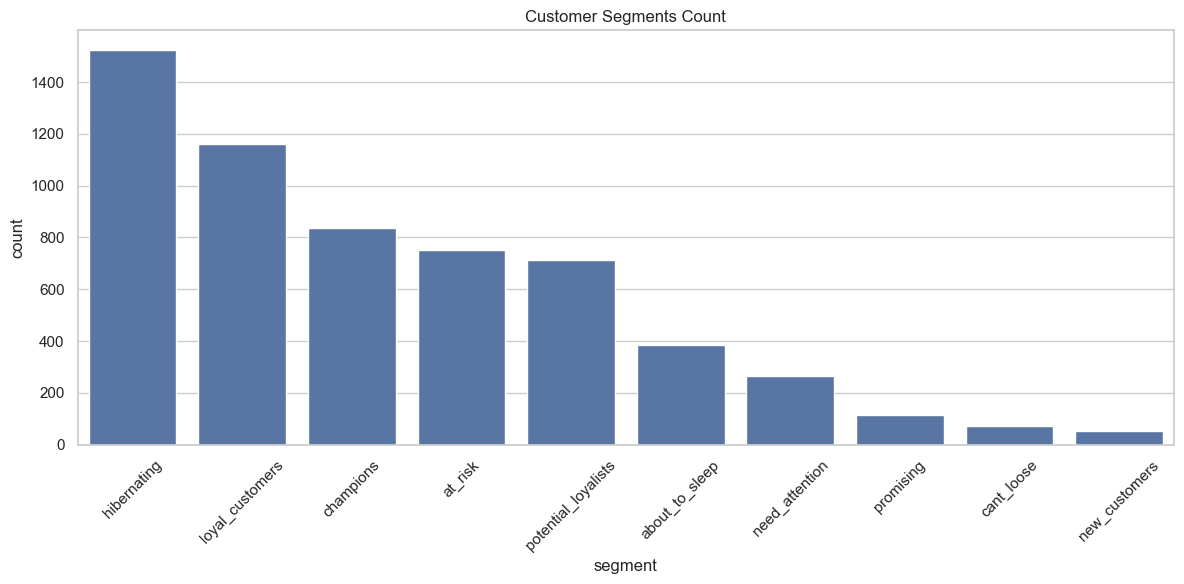

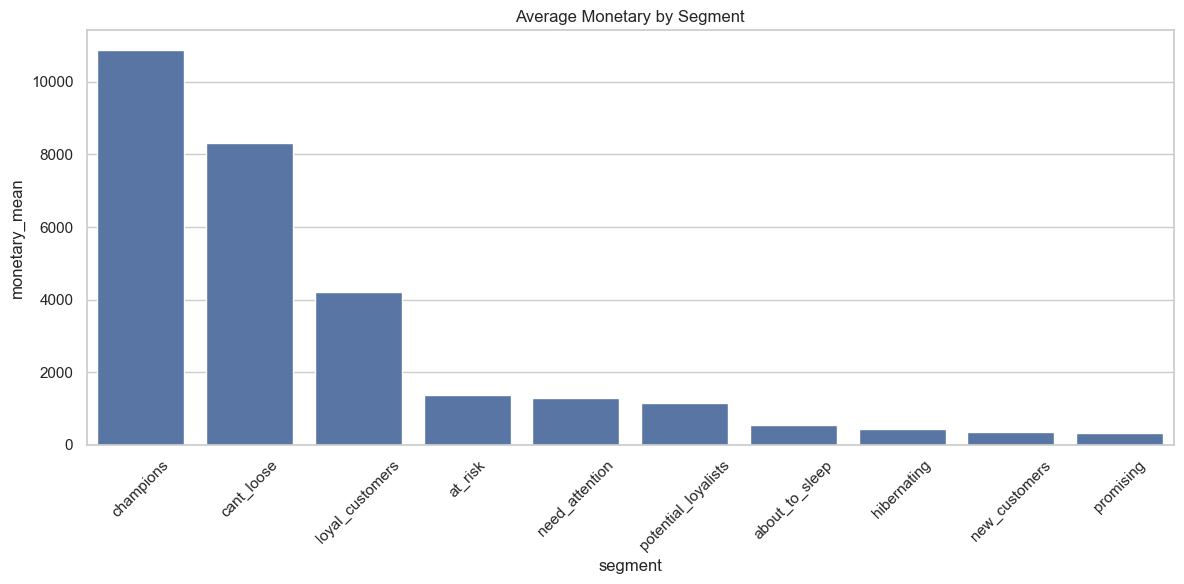

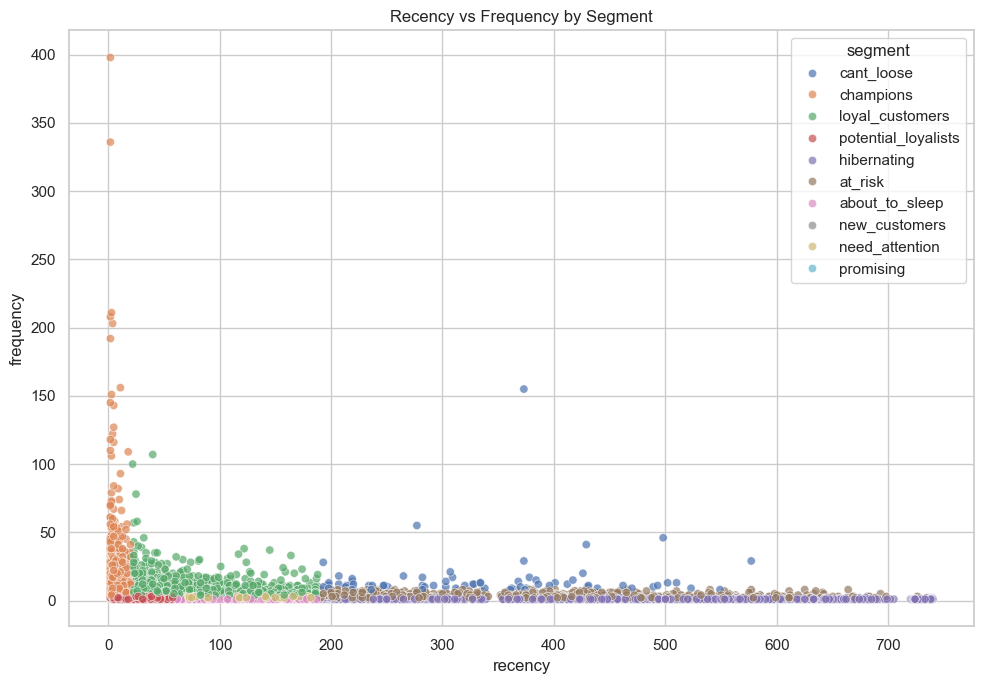

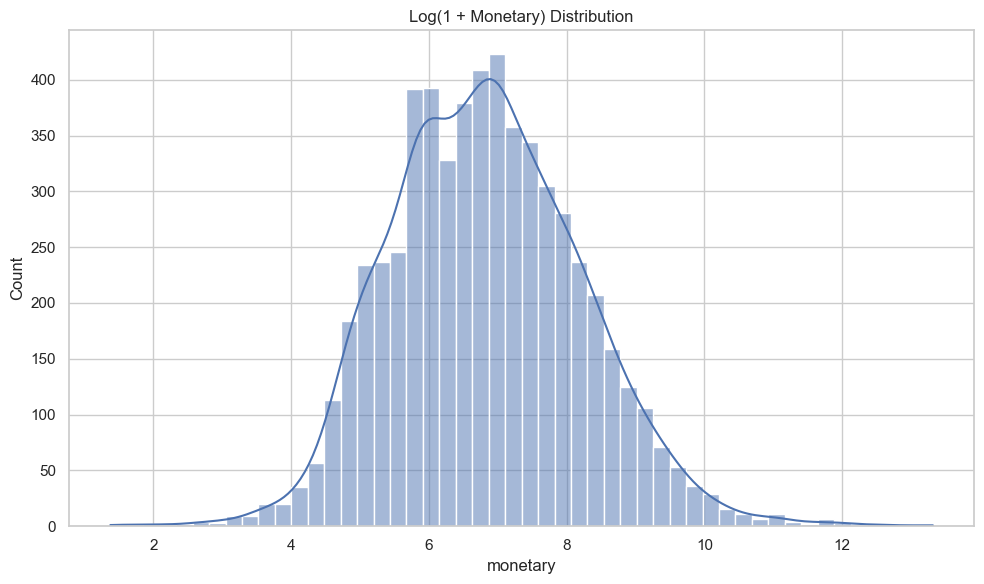


Country x Segment 摘要：
      Country              segment  total_sales  total_customers
3   Australia      loyal_customers   158,328.51                5
4   Australia       need_attention     4,443.46                2
1   Australia            champions     3,901.11                1
2   Australia          hibernating     1,794.20                6
0   Australia              at_risk     1,433.33                1
10    Austria  potential_loyalists     6,312.69                2
9     Austria      loyal_customers     5,304.71                2
6     Austria              at_risk     4,562.19                4
7     Austria            champions     4,325.05                2
8     Austria          hibernating     2,401.28                2
5     Austria       about_to_sleep       707.09                1
11    Bahrain          hibernating     1,354.37                2
16    Belgium      loyal_customers    26,337.77                7
14    Belgium            champions    20,118.19                5
18

In [4]:
# =========================================================
# RFM Analysis for Online Retail II
# Author: ChatGPT
# Environment: Google Colab
# =========================================================

# -----------------------------
# 1. 套件安裝 / 載入
# -----------------------------
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# -----------------------------
# 2. 指定檔案路徑
# -----------------------------
# 方法A：若您已把檔案放在 Colab 工作目錄
# file_path = "/content/online_retail_II.xlsx"
file_path = r'D:\colab0516\安裝包\姜老師\3-8-第四天\online_retail_II.xlsx\online_retail_II.xlsx'

# 方法B：若您放在 Google Drive，請改成您的實際路徑
# file_path = "/content/drive/MyDrive/Colab Notebooks/TEJ2026A/online_retail_II.xlsx"

# 如果要掛載 Google Drive，請取消下面註解
# from google.colab import drive
# drive.mount('/content/drive')

# -----------------------------
# 3. 讀取 Excel 所有工作表並合併
# -----------------------------
xls = pd.ExcelFile(file_path)
print("工作表名稱：", xls.sheet_names)

df_list = []
for sheet in xls.sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet)
    temp["SheetName"] = sheet
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print("\n原始資料筆數：", df.shape)
print(df.head())

# -----------------------------
# 4. 欄位名稱標準化
# -----------------------------
df.columns = [col.strip().replace(" ", "_") for col in df.columns]
# 例如 Customer ID -> Customer_ID

print("\n標準化後欄位：")
print(df.columns.tolist())

# -----------------------------
# 5. 基本資料型態處理
# -----------------------------
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Customer_ID"] = df["Customer_ID"].astype("string")
df["Invoice"] = df["Invoice"].astype("string")
df["StockCode"] = df["StockCode"].astype("string")

# 數值欄位轉換
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

print("\n資料型態：")
print(df.dtypes)

# -----------------------------
# 6. 缺失值檢查
# -----------------------------
print("\n缺失值統計：")
print(df.isnull().sum())

# -----------------------------
# 7. 建立原始備份
# -----------------------------
df_raw = df.copy()

# -----------------------------
# 8. 資料清理
# -----------------------------
# 8.1 移除 Customer_ID 缺失
df = df[~df["Customer_ID"].isna()].copy()

# 8.2 排除取消發票：Invoice 以 C 開頭
df = df[~df["Invoice"].str.startswith("C", na=False)].copy()

# 8.3 保留 Quantity > 0, Price > 0
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)].copy()

# 8.4 建立 TotalPrice
df["TotalPrice"] = df["Quantity"] * df["Price"]

# 8.5 去除完全重複列（可保守使用）
df = df.drop_duplicates()

print("\n清理後資料筆數：", df.shape)
print(df.head())

# -----------------------------
# 9. EDA：基本觀察
# -----------------------------
print("\n唯一顧客數：", df["Customer_ID"].nunique())
print("唯一發票數：", df["Invoice"].nunique())
print("日期範圍：", df["InvoiceDate"].min(), "到", df["InvoiceDate"].max())

# -----------------------------
# 10. 設定分析日（Analysis Date）
# -----------------------------
# 常見作法：用最後交易日 + 2 天
analysis_date = df["InvoiceDate"].max() + timedelta(days=2)
print("\n分析基準日 analysis_date =", analysis_date)

# -----------------------------
# 11. 建立 RFM 表
# -----------------------------
rfm = df.groupby("Customer_ID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,   # Recency
    "Invoice": "nunique",                                      # Frequency
    "TotalPrice": "sum"                                        # Monetary
})

rfm.columns = ["recency", "frequency", "monetary"]
rfm = rfm[(rfm["monetary"] > 0)]
rfm.head()

print("\nRFM 資料表：")
print(rfm.head())
print("\nRFM shape =", rfm.shape)

# -----------------------------
# 12. RFM 分數
# -----------------------------
# 為避免 qcut 因重複值報錯，frequency 先 rank
rfm["recency_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_SCORE"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str) +
    rfm["monetary_score"].astype(str)
)

# Kaggle 常見作法：用 RF 二維來做 segment
rfm["rfm_segment"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str)
)

seg_map = {
    r"[1-2][1-2]": "hibernating",
    r"[1-2][3-4]": "at_risk",
    r"[1-2][5]": "cant_loose",
    r"[3][1-2]": "about_to_sleep",
    r"[3][3]": "need_attention",
    r"[3-4][4-5]": "loyal_customers",
    r"[4][1]": "promising",
    r"[5][1]": "new_customers",
    r"[4-5][2-3]": "potential_loyalists",
    r"[5][4-5]": "champions"
}

rfm["segment"] = rfm["rfm_segment"].replace(seg_map, regex=True)

print("\n含分群之 RFM：")
print(rfm.head())

# -----------------------------
# 13. Segment 摘要表
# -----------------------------
segment_summary = rfm.groupby("segment").agg(
    customer_count=("segment", "count"),
    recency_mean=("recency", "mean"),
    frequency_mean=("frequency", "mean"),
    monetary_mean=("monetary", "mean"),
    monetary_sum=("monetary", "sum")
).sort_values("customer_count", ascending=False)

print("\nSegment 摘要表：")
print(segment_summary)

# -----------------------------
# 14. 各 segment 占比
# -----------------------------
segment_ratio = (
    rfm["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("ratio_pct")
    .to_frame()
)

print("\nSegment 占比（%）：")
print(segment_ratio)

# -----------------------------
# 15. 挑出重要客群名單
# -----------------------------
champions = rfm[rfm["segment"] == "champions"].sort_values("monetary", ascending=False)
loyal_customers = rfm[rfm["segment"] == "loyal_customers"].sort_values("monetary", ascending=False)
at_risk = rfm[rfm["segment"] == "at_risk"].sort_values("monetary", ascending=False)
cant_loose = rfm[rfm["segment"] == "cant_loose"].sort_values("monetary", ascending=False)

print("\nChampions 前10名：")
print(champions.head(10))

print("\nAt Risk 前10名：")
print(at_risk.head(10))

# -----------------------------
# 16. 視覺化
# -----------------------------
sns.set_theme(style="whitegrid")

# 16.1 Segment 人數長條圖
plt.figure(figsize=(12, 6))
order = rfm["segment"].value_counts().index
sns.countplot(data=rfm.reset_index(), x="segment", order=order)
plt.title("Customer Segments Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16.2 各 segment 平均 Monetary
plt.figure(figsize=(12, 6))
tmp = segment_summary.sort_values("monetary_mean", ascending=False).reset_index()
sns.barplot(data=tmp, x="segment", y="monetary_mean")
plt.title("Average Monetary by Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 16.3 Recency vs Frequency 散點圖
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=rfm.reset_index(),
    x="recency",
    y="frequency",
    hue="segment",
    alpha=0.7
)
plt.title("Recency vs Frequency by Segment")
plt.tight_layout()
plt.show()

# 16.4 Monetary 分布（對數較容易看）
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(rfm["monetary"]), bins=50, kde=True)
plt.title("Log(1 + Monetary) Distribution")
plt.tight_layout()
plt.show()

# -----------------------------
# 17. Segment x 國家（選做）
# -----------------------------
# 若您想把 segment 回接到交易資料分析國家結構
df_segmented = df.merge(rfm.reset_index()[["Customer_ID", "segment"]], on="Customer_ID", how="left")

country_segment_summary = (
    df_segmented.groupby(["Country", "segment"])
    .agg(
        total_sales=("TotalPrice", "sum"),
        total_customers=("Customer_ID", "nunique")
    )
    .reset_index()
    .sort_values(["Country", "total_sales"], ascending=[True, False])
)

print("\nCountry x Segment 摘要：")
print(country_segment_summary.head(20))

# -----------------------------
# 18. 匯出結果
# -----------------------------
rfm_export = rfm.reset_index().copy()
segment_summary_export = segment_summary.reset_index().copy()

rfm_export.to_csv("D:/colab0516/安裝包/姜老師/3-8-第四天/content/rfm_customers.csv", index=False, encoding="utf-8-sig")
segment_summary_export.to_csv("D:/colab0516/安裝包/姜老師/3-8-第四天/content/rfm_segment_summary.csv", index=False, encoding="utf-8-sig")
champions.reset_index().to_csv("D:/colab0516/安裝包/姜老師/3-8-第四天/content/rfm_champions.csv", index=False, encoding="utf-8-sig")
at_risk.reset_index().to_csv("D:/colab0516/安裝包/姜老師/3-8-第四天/content/rfm_at_risk.csv", index=False, encoding="utf-8-sig")


#-------------------------------------------------------------
import os
# 取得目前程式執行目錄
base_dir = os.getcwd()
# 建立 content 完整路徑
content_dir = os.path.join(base_dir, "content")+os.path.sep
# 建立資料夾
os.makedirs(content_dir, exist_ok=True)
print("content 目錄 =", content_dir)
#-------------------------------------------------------------
print("content 目錄 =", content_dir)
print("\n已匯出檔案：")
print(f"{content_dir}rfm_customers.csv")
print(f"{content_dir}rfm_segment_summary.csv")
print(f"{content_dir}rfm_champions.csv")
print(f"{content_dir}rfm_at_risk.csv")

# -----------------------------
# 19. 行銷建議範例
# -----------------------------
marketing_actions = {
    "champions": "高價值且近期活躍：適合VIP活動、優先新品、交叉銷售",
    "loyal_customers": "忠誠顧客：適合會員分級、點數回饋、長期關係經營",
    "potential_loyalists": "具忠誠潛力：適合首購後培養與加購推薦",
    "new_customers": "新客戶：適合 onboarding、品牌介紹、首購優惠",
    "promising": "有潛力的新進顧客：適合個人化推薦",
    "need_attention": "需要關注：可透過提醒與優惠券喚回",
    "about_to_sleep": "快沉睡：可投放再行銷廣告",
    "at_risk": "流失風險高：適合召回活動、限時優惠",
    "cant_loose": "不能失去：需高優先級挽回策略",
    "hibernating": "沉睡顧客：低成本喚醒或重新分流"
}

action_df = pd.DataFrame(
    list(marketing_actions.items()),
    columns=["segment", "suggested_action"]
)

final_segment_report = segment_summary_export.merge(action_df, on="segment", how="left")
print("\n最終分群建議表：")
print(final_segment_report)

content 目錄 = d:\colab0516\安裝包\姜老師\3-8-第四天\content\
